# Optimizing MNIST Digit Classification through Micro-Residual Neural Networks (Micro-ResNet)

While traditional sequential Convolutional Neural Networks (CNNs) provide a solid baseline for image classification, they often encounter gradient flow bottlenecks as network depth increases. In this project, rather than relying solely on standard regularization techniques, we introduce a custom-built Micro-Residual Network (Micro-ResNet) to tackle the MNIST dataset. By implementing skip connections (residual blocks), we provide a shortcut for gradient propagation during backpropagation. This architectural enhancement not only mitigates the degradation problem but also allows for highly efficient feature extraction. The result is a lightweight yet powerful model capable of achieving rapid convergence and superior generalization on unseen data.

<small>Created by: Yosef (N16157011) and Jack (N16141662)\
Department of Mechanical Engineering, National Cheng Kung University

# Import Library

In [25]:
import sys
!{sys.executable} -m pip uninstall protobuf -y
!{sys.executable} -m pip install protobuf==3.20.3
!{sys.executable} -m pip install --upgrade tensorflow-datasets

Found existing installation: protobuf 7.35.1
Uninstalling protobuf-7.35.1:
  Successfully uninstalled protobuf-7.35.1
  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-datastore 2.25.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grpc-google-iam-v1 0.14.4 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.
google-cloud-dataplex 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.3 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-bigquery-stor

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import gdown
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive
from sklearn.metrics import confusion_matrix

# Reproducibility

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

# Micro-ResNet Definition

In [3]:
def build_perfect_hybrid_cnn(
  x_train_len,
  epochs,
  input_shape=(28, 28, 1),
  num_classes=10,
):

  AUG_ROTATION = 0.05
  AUG_ZOOM = 0.05
  AUG_SHIFT = 0.05

  total_decay_steps = (x_train_len // 64) * epochs

  inputs = layers.Input(shape=input_shape)

  # Data augmentation
  x = layers.RandomRotation(AUG_ROTATION)(inputs)
  x = layers.RandomZoom(AUG_ZOOM)(x)
  x = layers.RandomTranslation(AUG_SHIFT, AUG_SHIFT)(x)

  # Initial convolution
  x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("swish")(x)

  # Residual block 1
  shortcut = x
  x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("swish")(x)
  x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Add()([shortcut, x])
  x = layers.Activation("swish")(x)
  x = layers.MaxPooling2D((2, 2))(x)
  x = layers.Dropout(0.10)(x)

  # Residual block 2
  shortcut = layers.Conv2D(64, (1, 1), padding="same", use_bias=False)(x)
  shortcut = layers.BatchNormalization()(shortcut)

  x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("swish")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Add()([shortcut, x])
  x = layers.Activation("swish")(x)
  x = layers.MaxPooling2D((2, 2))(x)
  x = layers.Dropout(0.15)(x)

  # Residual block 3
  shortcut = layers.Conv2D(128, (1, 1), padding="same", use_bias=False)(x)
  shortcut = layers.BatchNormalization()(shortcut)

  x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("swish")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.Add()([shortcut, x])
  x = layers.Activation("swish")(x)
  x = layers.MaxPooling2D((2, 2))(x)
  # x = layers.Dropout(0.20)(x)

  # Classification head
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.20)(x) # If the effect is not good, change it to 0.25
  outputs = layers.Dense(num_classes, activation="softmax")(x)

  model = models.Model(inputs, outputs)

  lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_decay_steps,
    alpha=0.01
  )

  model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
  )

  return model

# Callback Builder

In [4]:
def build_callbacks(filename):

  early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
  )

  checkpoint = ModelCheckpoint(
    filename,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
  )

  return [early_stop, checkpoint]

# MNIST Experiment

In [5]:
def run_mnist():
  print("="*50)
  print("MNIST Experiment")
  print("="*50)

  BATCH_SIZE = 64
  EPOCHS = 100

  (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

  x_train = x_train.astype("float32") / 255.0
  x_test = x_test.astype("float32") / 255.0
  x_train = np.expand_dims(x_train, -1)
  x_test = np.expand_dims(x_test, -1)
  y_train = tf.keras.utils.to_categorical(y_train, 10)
  y_test = tf.keras.utils.to_categorical(y_test, 10)

  # Simplified model call
  model = build_perfect_hybrid_cnn(
    x_train_len=len(x_train),
    epochs=EPOCHS,
    num_classes=10
  )

  callbacks = build_callbacks("Best_MNIST_Model.h5")

  history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
  )

  model.load_weights("Best_MNIST_Model.h5")
  train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

  print(f"Train Accuracy : {train_acc:.4f}")
  print(f"Test Accuracy  : {test_acc:.4f}")

  return model, history

# EMNIST Dataset Preparation

In [6]:
def prepare_emnist():
    # Load the 'byclass' split which has all 62 classes
    ds_train, ds_test = tfds.load("emnist/byclass", split=["train", "test"], as_supervised=True)

    def get_filtered_data(ds):
        x_list, y_list = [], []
        for x_batch, y_batch in tfds.as_numpy(ds.batch(2048)):
            mask = y_batch < 36
            if np.any(mask):
                x_list.append(x_batch[mask])
                y_list.append(y_batch[mask])
        return np.concatenate(x_list, axis=0), np.concatenate(y_list, axis=0)

    x_train, y_train = get_filtered_data(ds_train)
    x_test, y_test = get_filtered_data(ds_test)

    print(f"Unique labels captured: {np.unique(y_test)}")

    indices = np.arange(len(x_train))
    np.random.seed(42)
    np.random.shuffle(indices)
    x_train, y_train = x_train[indices], y_train[indices]

    # Normalize and Transpose (EMNIST images are rotated/flipped by default)
    x_train = np.transpose(x_train.astype("float32") / 255.0, (0, 2, 1, 3))
    x_test = np.transpose(x_test.astype("float32") / 255.0, (0, 2, 1, 3))

    # One-hot encoding for 36 classes
    y_train = tf.keras.utils.to_categorical(y_train, 36)
    y_test = tf.keras.utils.to_categorical(y_test, 36)

    return x_train, y_train, x_test, y_test

# Load EMNIST Dataset

In [7]:
def load_emnist_dataset_v2():
    file_path = 'EMNIST_FULL_36.npz'
    if os.path.exists(file_path):
        data = np.load(file_path)
        return data['x_train'], data['y_train'], data['x_test'], data['y_test']

    x_train, y_train, x_test, y_test = prepare_emnist()
    np.savez_compressed(file_path, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
    print("Generation complete.")
    return x_train, y_train, x_test, y_test

# EMNIST Training

In [8]:
def run_emnist():
  BATCH_SIZE = 64
  EPOCHS = 100

  x_train, y_train, x_test, y_test = load_emnist_dataset_v2()

  model = build_perfect_hybrid_cnn(
    x_train_len=len(x_train),
    epochs=EPOCHS,
    num_classes=36
  )

  callbacks = build_callbacks("Best_EMNIST_Model.h5")

  history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
  )

  model.load_weights("Best_EMNIST_Model.h5")
  train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

  print(f'Train Accuracy : {train_acc:.4f}')
  print(f'Test Accuracy  : {test_acc:.4f}')
  return model, history

# Main

In [9]:
# Run MNIST experiment first
mnist_model, mnist_history = run_mnist()

MNIST Experiment
Epoch 1/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8364 - loss: 0.9810
Epoch 1: val_accuracy improved from None to 0.98433, saving model to Best_MNIST_Model.h5



Epoch 1: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.9351 - loss: 0.7240 - val_accuracy: 0.9843 - val_loss: 0.5792
Epoch 2/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9835 - loss: 0.5876
Epoch 2: val_accuracy improved from 0.98433 to 0.99283, saving model to Best_MNIST_Model.h5



Epoch 2: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9849 - loss: 0.5796 - val_accuracy: 0.9928 - val_loss: 0.5444
Epoch 3/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9879 - loss: 0.5637
Epoch 3: val_accuracy improved from 0.99283 to 0.99350, saving model to Best_MNIST_Model.h5



Epoch 3: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9890 - loss: 0.5591 - val_accuracy: 0.9935 - val_loss: 0.5345
Epoch 4/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9903 - loss: 0.5526
Epoch 4: val_accuracy did not improve from 0.99350
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9909 - loss: 0.5500 - val_accuracy: 0.9920 - val_loss: 0.5329
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9916 - loss: 0.5455
Epoch 5: val_accuracy improved from 0.99350 to 0.99483, saving model to Best_MNIST_Model.h5



Epoch 5: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9919 - loss: 0.5442 - val_accuracy: 0.9948 - val_loss: 0.5282
Epoch 6/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9928 - loss: 0.5403
Epoch 6: val_accuracy improved from 0.99483 to 0.99550, saving model to Best_MNIST_Model.h5



Epoch 6: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9929 - loss: 0.5394 - val_accuracy: 0.9955 - val_loss: 0.5250
Epoch 7/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9928 - loss: 0.5371
Epoch 7: val_accuracy improved from 0.99550 to 0.99633, saving model to Best_MNIST_Model.h5



Epoch 7: finished saving model to Best_MNIST_Model.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9933 - loss: 0.5361 - val_accuracy: 0.9963 - val_loss: 0.5214
Epoch 8/100
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9942 - loss: 0.5333
Epoch 8: val_accuracy did not improve from 0.99633
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9943 - loss: 0.5326 - val_accuracy: 0.9960 - val_loss: 0.5211
Epoch 9/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9949 - loss: 0.5315
Epoch 9: val_accuracy did not improve from 0.99633
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9950 - loss: 0.5310 - val_accuracy: 0.9962 - val_loss: 0.5201
Epoch 10/100
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9952 - loss: 0.5288
Epoch 10: val_accuracy did not improve from 0.99633
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9951 - loss: 0.5286 - val_accuracy: 0.9953 - val_loss: 0.5206
Epoch 11/100
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/

In [10]:
# Then train on EMNIST
emnist_model, emnist_history = run_emnist()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...


Epoch 6: finished saving model to Best_EMNIST_Model.h5
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 183s 24ms/step - accuracy: 0.9332 - loss: 0.8318 - val_accuracy: 0.9346 - val_loss: 0.8201
Epoch 7/100
7509/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9332 - loss: 0.8301
Epoch 7: val_accuracy did not improve from 0.93457
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 178s 24ms/step - accuracy: 0.9341 - loss: 0.8287 - val_accuracy: 0.9326 - val_loss: 0.8222
Epoch 8/100
7508/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9340 - loss: 0.8281
Epoch 8: val_accuracy did not improve from 0.93457
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 202s 24ms/step - accuracy: 0.9347 - loss: 0.8266 - val_accuracy: 0.9340 - val_loss: 0.8179
Epoch 9/100
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9347 - loss: 0.8260
Epoch 9: val_accuracy improved from 0.93457 to 0.93491, saving model to Best_EMNIST_Model.h5



Epoch 9: finished saving model to Best_EMNIST_Model.h5
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 178s 24ms/step - accuracy: 0.9355 - loss: 0.8246 - val_accuracy: 0.9349 - val_loss: 0.8156
Epoch 10/100
7509/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9349 - loss: 0.8240
Epoch 10: val_accuracy did not improve from 0.93491
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 178s 24ms/step - accuracy: 0.9356 - loss: 0.8230 - val_accuracy: 0.9349 - val_loss: 0.8154
Epoch 11/100
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9356 - loss: 0.8229
Epoch 11: val_accuracy improved from 0.93491 to 0.93601, saving model to Best_EMNIST_Model.h5



Epoch 11: finished saving model to Best_EMNIST_Model.h5
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 201s 24ms/step - accuracy: 0.9360 - loss: 0.8217 - val_accuracy: 0.9360 - val_loss: 0.8122
Epoch 12/100
7509/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9361 - loss: 0.8215
Epoch 12: val_accuracy improved from 0.93601 to 0.93652, saving model to Best_EMNIST_Model.h5



Epoch 12: finished saving model to Best_EMNIST_Model.h5
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 179s 24ms/step - accuracy: 0.9367 - loss: 0.8202 - val_accuracy: 0.9365 - val_loss: 0.8107
Epoch 13/100
7508/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9363 - loss: 0.8198
Epoch 13: val_accuracy improved from 0.93652 to 0.93700, saving model to Best_EMNIST_Model.h5



Epoch 13: finished saving model to Best_EMNIST_Model.h5
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 177s 24ms/step - accuracy: 0.9369 - loss: 0.8190 - val_accuracy: 0.9370 - val_loss: 0.8115
Epoch 14/100
7509/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9370 - loss: 0.8192
Epoch 14: val_accuracy did not improve from 0.93700
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 177s 24ms/step - accuracy: 0.9375 - loss: 0.8182 - val_accuracy: 0.9367 - val_loss: 0.8111
Epoch 15/100
7508/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9368 - loss: 0.8182
Epoch 15: val_accuracy did not improve from 0.93700
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 178s 24ms/step - accuracy: 0.9373 - loss: 0.8172 - val_accuracy: 0.9362 - val_loss: 0.8124
Epoch 16/100
7508/7510 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9376 - loss: 0.8172
Epoch 16: val_accuracy did not improve from 0.93700
7510/7510 ━━━━━━━━━━━━━━━━━━━━ 177s 24ms/step - accuracy: 0.9380 - loss: 0.8163 - val_accuracy: 0.9352 - val_loss: 0.8131
Epoch 17/100
7509/7510 ━━━

## Plot Loss-Accuracy Curves

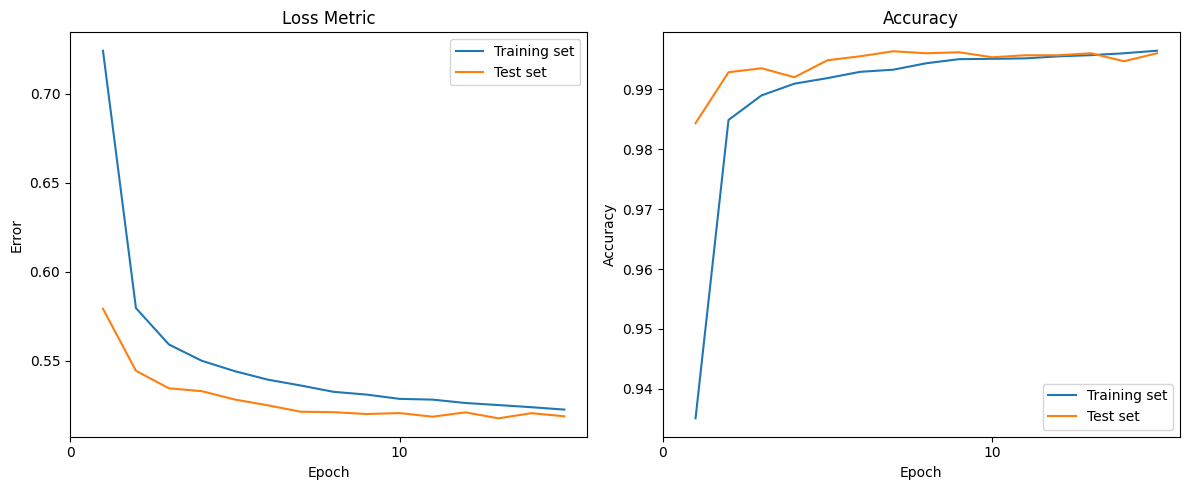


Best Validation Accuracy (MNIST): 99.63% at Epoch 7


In [11]:
# MNIST
train_loss = mnist_history.history['loss']
val_loss = mnist_history.history['val_loss']
train_acc = mnist_history.history['accuracy']
val_acc = mnist_history.history['val_accuracy']
EPOCHS = len(train_loss)
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Training set")
plt.plot(epochs, val_loss, label="Test set")
plt.title("Loss Metric")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
plt.legend()
plt.grid(False)
min_loss = min(min(train_loss), min(val_loss))
max_loss = max(max(train_loss), max(val_loss))
loss_range = max_loss - min_loss
plt.ylim(min_loss - 0.05 * loss_range, max_loss + 0.05 * loss_range)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label="Training set")
plt.plot(epochs, val_acc, label="Test set")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
min_acc = min(min(train_acc), min(val_acc))
max_acc = max(max(train_acc), max(val_acc))
acc_range = max_acc - min_acc
plt.ylim(min_acc - 0.05 * acc_range, max_acc + 0.05 * acc_range)
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# Best test accuracy within full range
best_val_acc = max(val_acc)
best_epoch = val_acc.index(best_val_acc)
print(f"\nBest Validation Accuracy (MNIST): {best_val_acc * 100:.2f}% at Epoch {best_epoch + 1}")

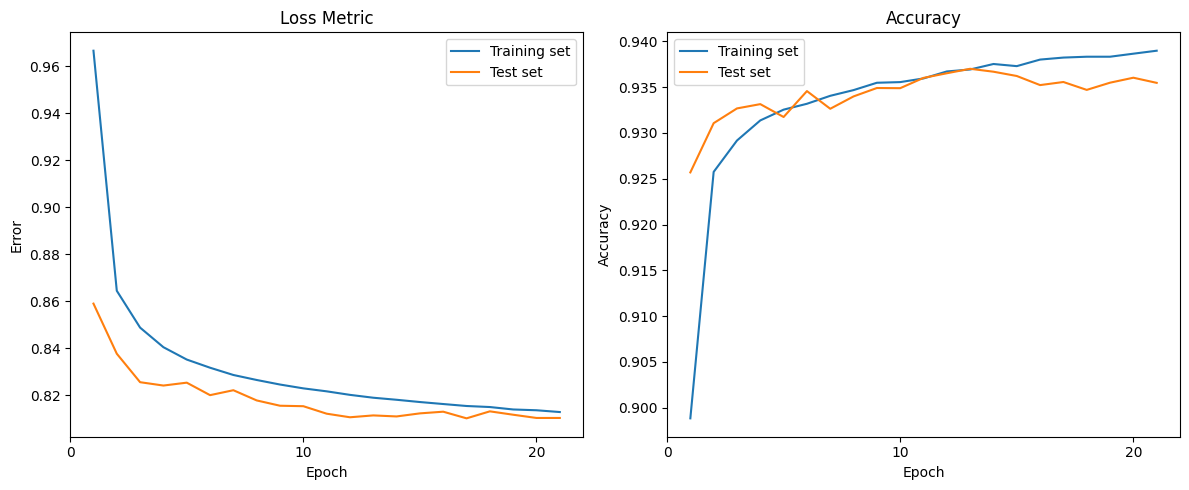


Best Validation Accuracy (EMNIST): 93.70% at Epoch 13


In [12]:
# EMNIST
train_loss = emnist_history.history['loss']
val_loss = emnist_history.history['val_loss']
train_acc = emnist_history.history['accuracy']
val_acc = emnist_history.history['val_accuracy']
EPOCHS = len(train_loss)
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Training set")
plt.plot(epochs, val_loss, label="Test set")
plt.title("Loss Metric")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
plt.legend()
plt.grid(False)
min_loss = min(min(train_loss), min(val_loss))
max_loss = max(max(train_loss), max(val_loss))
loss_range = max_loss - min_loss
plt.ylim(min_loss - 0.05 * loss_range, max_loss + 0.05 * loss_range)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label="Training set")
plt.plot(epochs, val_acc, label="Test set")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
min_acc = min(min(train_acc), min(val_acc))
max_acc = max(max(train_acc), max(val_acc))
acc_range = max_acc - min_acc
plt.ylim(min_acc - 0.05 * acc_range, max_acc + 0.05 * acc_range)
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# Best test accuracy within full range
best_val_acc = max(val_acc)
best_epoch = val_acc.index(best_val_acc)
print(f"\nBest Validation Accuracy (EMNIST): {best_val_acc * 100:.2f}% at Epoch {best_epoch + 1}")

## Visualize Confusion Matrix

2790/2790 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


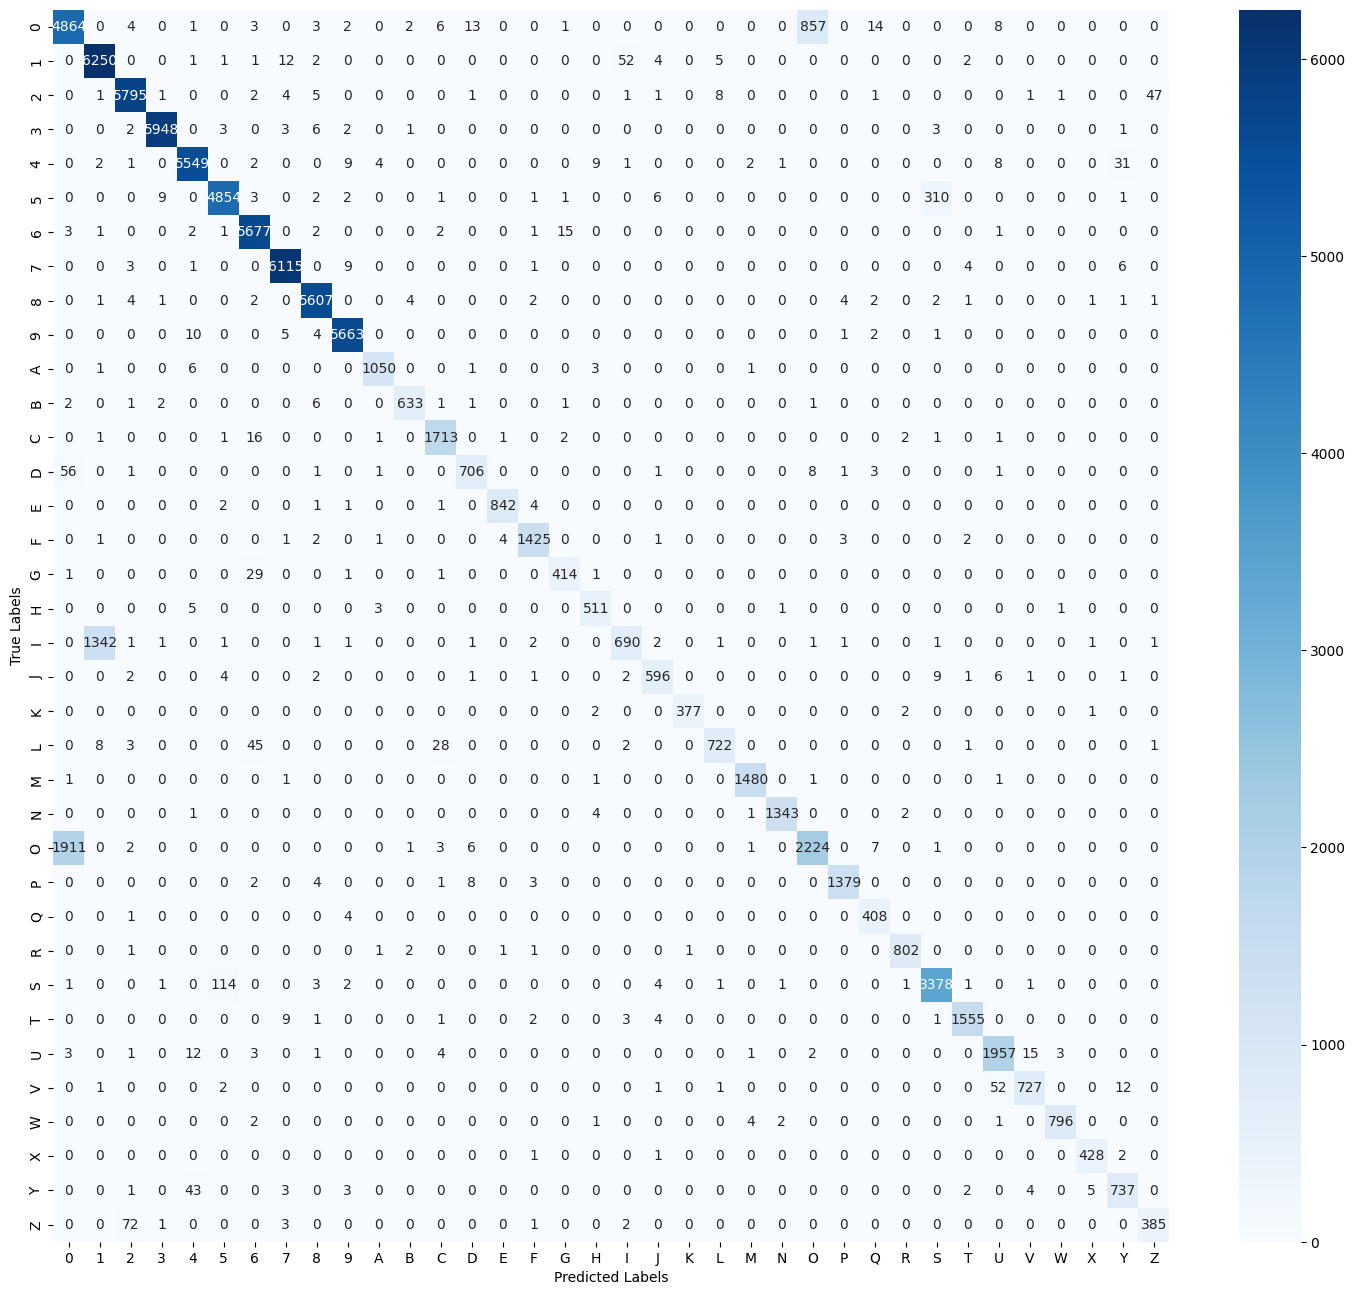

In [13]:
# Mapping labels to characters
def label_to_char(label):
    if label < 10:
        return str(label)
    else:
        return chr(ord('A') + label - 10)

# Pointing to the full dataset for the confusion matrix
_, _, x_test, y_test = load_emnist_dataset_v2()

y_pred_probs = emnist_model.predict(x_test)
predicted_labels = np.argmax(y_pred_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)

num_classes = 36
cm = confusion_matrix(true_labels, predicted_labels)
labels_char = [label_to_char(i) for i in range(num_classes)]

plt.figure(figsize=(18,16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_char, yticklabels=labels_char)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [14]:
# Load the full dataset to ensure all classes are present
_, _, x_test_full, y_test_full = load_emnist_dataset_v2()

# Calculate per-class accuracy for the Keras model
class_correct = [0. for _ in range(num_classes)]
class_total = [0. for _ in range(num_classes)]

# Get predictions from the Keras model using the full test set
y_pred_probs = emnist_model.predict(x_test_full, verbose=0)
predicted_labels = np.argmax(y_pred_probs, axis=1)
true_labels = np.argmax(y_test_full, axis=1)

for i in range(len(true_labels)):
    label = true_labels[i]
    if predicted_labels[i] == label:
        class_correct[label] += 1
    class_total[label] += 1

# Print per-class accuracy
print("Per-class Accuracy:")
print("-" * 30)
for i in range(num_classes):
    char_label = label_to_char(i)
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'Label {char_label}: {accuracy:.2f}% ({int(class_correct[i])}/{int(class_total[i])})')
    else:
        print(f'Label {char_label}: No samples in test set')

# Find most Confused Pairs
print("\nMost Confused Pairs:")
print("-" * 30)
cm = confusion_matrix(true_labels, predicted_labels, labels=range(num_classes))
cm_normalized = np.zeros_like(cm, dtype=float)
sum_rows = cm.sum(axis=1)
for i in range(num_classes):
    if sum_rows[i] > 0:
        cm_normalized[i, :] = cm[i, :].astype('float') / sum_rows[i]
np.fill_diagonal(cm_normalized, 0)
confused_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and sum_rows[i] > 0 and cm_normalized[i, j] > 0.005:
            confused_pairs.append((label_to_char(i), label_to_char(j), cm_normalized[i, j]))
confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_label_char, pred_label_char, conf_rate in confused_pairs[:10]:
    print(f"{true_label_char} → {pred_label_char}: {conf_rate*100:.1f}%")

Per-class Accuracy:
------------------------------
Label 0: 84.18% (4864/5778)
Label 1: 98.74% (6250/6330)
Label 2: 98.74% (5795/5869)
Label 3: 99.65% (5948/5969)
Label 4: 98.75% (5549/5619)
Label 5: 93.53% (4854/5190)
Label 6: 99.51% (5677/5705)
Label 7: 99.61% (6115/6139)
Label 8: 99.54% (5607/5633)
Label 9: 99.60% (5663/5686)
Label A: 98.87% (1050/1062)
Label B: 97.69% (633/648)
Label C: 98.50% (1713/1739)
Label D: 90.63% (706/779)
Label E: 98.94% (842/851)
Label F: 98.96% (1425/1440)
Label G: 92.62% (414/447)
Label H: 98.08% (511/521)
Label I: 33.69% (690/2048)
Label J: 95.21% (596/626)
Label K: 98.69% (377/382)
Label L: 89.14% (722/810)
Label M: 99.66% (1480/1485)
Label N: 99.41% (1343/1351)
Label O: 53.51% (2224/4156)
Label P: 98.71% (1379/1397)
Label Q: 98.79% (408/413)
Label R: 99.13% (802/809)
Label S: 96.29% (3378/3508)
Label T: 98.67% (1555/1576)
Label U: 97.75% (1957/2002)
Label V: 91.33% (727/796)
Label W: 98.76% (796/806)
Label X: 99.07% (428/432)
Label Y: 92.36% (737/798

## Sample Predictions with Confidence

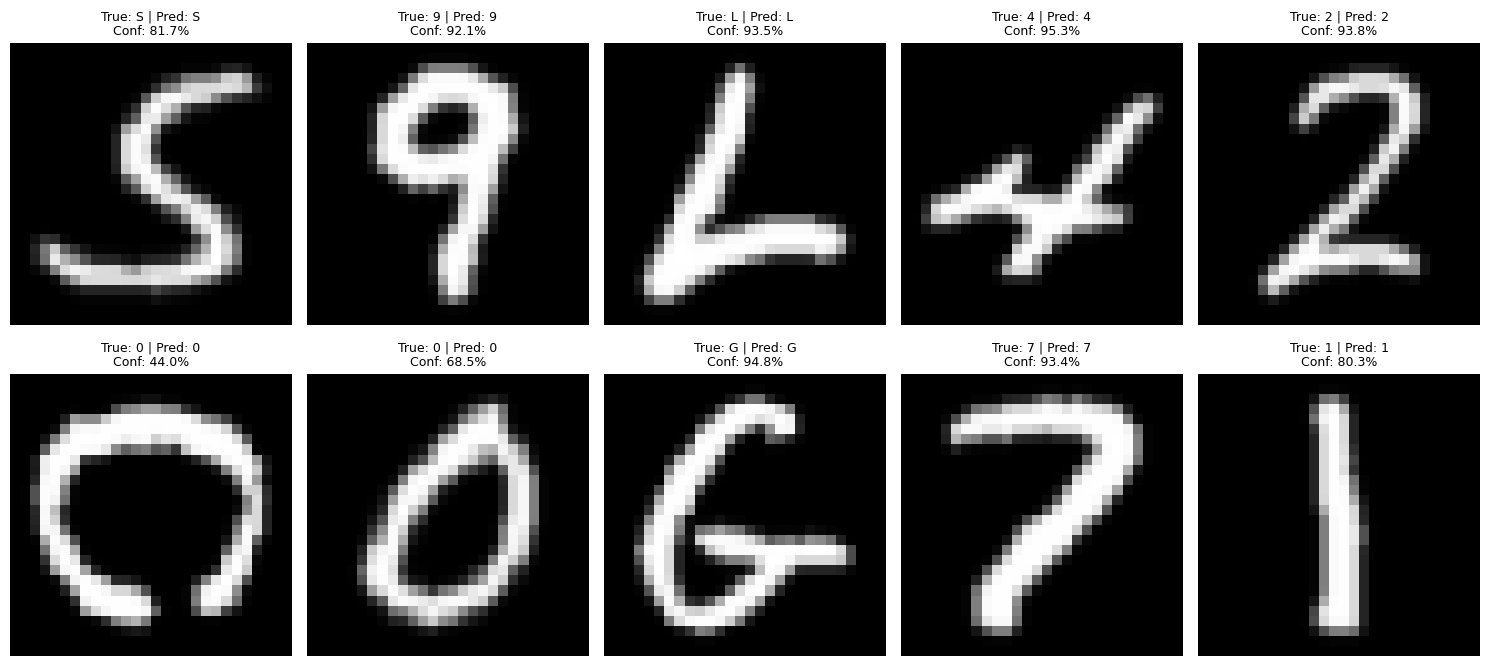

In [15]:
def show_true_model_predictions(model, x_test, y_test, num_images=10, cols=5):
    y_pred_probs = model.predict(x_test, verbose=0)
    predicted_labels = np.argmax(y_pred_probs, axis=1)
    confidences = np.max(y_pred_probs, axis=1) * 100
    true_labels = np.argmax(y_test, axis=1)

    # Filter only correct indices
    correct_indices = [i for i in range(len(true_labels)) if predicted_labels[i] == true_labels[i]]
    # Randomize sample
    sample_indices = random.sample(correct_indices, min(num_images, len(correct_indices)))

    rows = (len(sample_indices) + cols - 1) // cols
    plt.figure(figsize=(15, 3.5 * rows))

    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        title_str = f"True: {label_to_char(true_labels[idx])} | Pred: {label_to_char(predicted_labels[idx])}\nConf: {confidences[idx]:.1f}%"
        plt.title(title_str, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Trigger visualization
show_true_model_predictions(emnist_model, x_test_full, y_test_full)

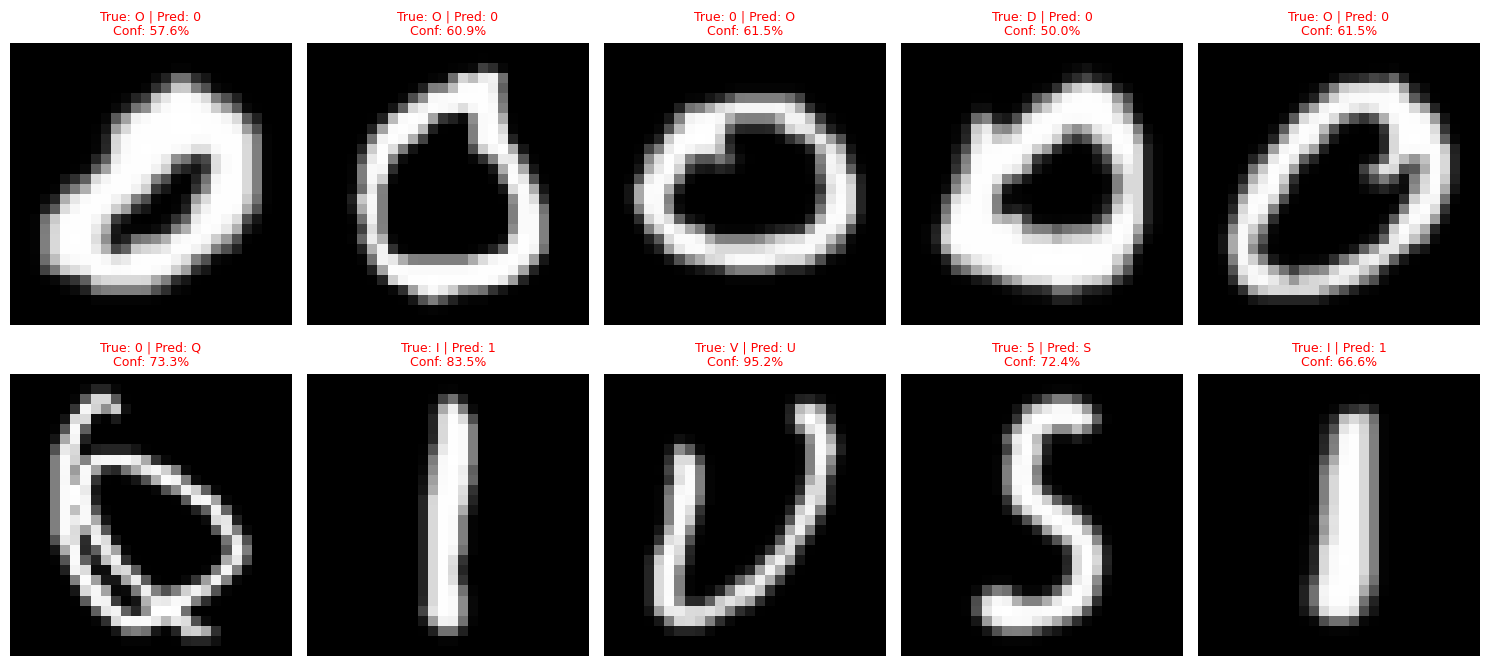

In [16]:
import random

def show_false_model_predictions(model, x_test, y_test, num_images=10, cols=5):
    y_pred_probs = model.predict(x_test, verbose=0)
    predicted_labels = np.argmax(y_pred_probs, axis=1)
    confidences = np.max(y_pred_probs, axis=1) * 100
    true_labels = np.argmax(y_test, axis=1)

    # Filter only incorrect indices
    incorrect_indices = [i for i in range(len(true_labels)) if predicted_labels[i] != true_labels[i]]
    # Randomize sample
    sample_indices = random.sample(incorrect_indices, min(num_images, len(incorrect_indices)))

    rows = (len(sample_indices) + cols - 1) // cols
    plt.figure(figsize=(15, 3.5 * rows))

    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
        title_str = f"True: {label_to_char(true_labels[idx])} | Pred: {label_to_char(predicted_labels[idx])}\nConf: {confidences[idx]:.1f}%"
        plt.title(title_str, fontsize=9, color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Trigger visualization
show_false_model_predictions(emnist_model, x_test_full, y_test_full)

## Model Summary

In [17]:
# Final evaluation using the correct full dataset
_, _, x_test_final, y_test_final = load_emnist_dataset_v2()

test_loss, test_accuracy = emnist_model.evaluate(
    x_test_final,
    y_test_final,
    verbose=0
)

test_accuracy_percent = test_accuracy * 100
test_error_percent = (1 - test_accuracy) * 100

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy_percent:.2f}%")
print(f"Test error: {test_error_percent:.2f}%")

Test loss: 0.8105
Test accuracy: 93.65%
Test error: 6.35%


## Save Model

In [20]:
error_rate = (1 - test_accuracy) * 100
filename = (
    f"EMNIST_{error_rate:.2f}%"
    "_Yosef_Budiman.h5"
  )

emnist_model.save(filename)
print(f"EMNIST model saved to {filename}")

EMNIST model saved to EMNIST_6.35%_Yosef_Budiman.h5
